# RQ3 — Spatial Clustering of Housing Equity in Southwark

**Research Question:** Are low housing equity areas spatially clustered within Southwark?

**Note on HEI direction:** HEI_bayes (Bayesian Latent Index) is coded **higher = more deprived** (worse housing equity).  
Therefore:
- **High-High (HH)** cluster = LSOAs of *poor* equity surrounded by *poor* equity → **deprivation hotspots**
- **Low-Low (LL)** cluster = LSOAs of *good* equity surrounded by *good* equity → **equity coldspots**
- The RQ's "低分区域" (low-equity areas) corresponds to **HH clusters** in HEI space

**Pipeline:**
1. Spatial weights matrix (Queen contiguity)
2. Global Moran's I — overall spatial autocorrelation
3. Local Moran's I (LISA) — cluster & outlier types
4. LISA cluster map + HH / LL identification

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats

import libpysal
from libpysal.weights import Queen
from esda.moran import Moran, Moran_Local

import os, warnings
warnings.filterwarnings('ignore')

pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams.update({'figure.dpi': 130, 'font.family': 'sans-serif'})

BASE    = os.path.dirname(os.path.abspath('__file__'))
DATA    = os.path.join(BASE, 'data')
SHP_DIR = os.path.join(BASE, 'LSOA_Shapfile')

print('Setup complete.')

Setup complete.


## 1. Load Data & Build GeoDataFrame

In [2]:
# Indices from RQ2
idx = pd.read_csv(os.path.join(DATA, 'southwark_indices.csv'))
idx = idx.drop_duplicates(subset=['lsoa21cd']).reset_index(drop=True)
print(f'Indices: {idx.shape}')

# Shapefile
gdf = gpd.read_file(os.path.join(SHP_DIR, 'Southwark.shp')).to_crs(epsg=27700)

# Drop columns from idx that already exist in shapefile to avoid _x/_y suffixes
shp_extra = set(gdf.columns) - {'geometry', 'lsoa21cd'}
idx_merge  = idx.drop(columns=[c for c in shp_extra if c in idx.columns], errors='ignore')

# Merge
geo = gdf.merge(idx_merge, on='lsoa21cd', how='left')

# Drop rows where HEI_bayes is missing (can't run spatial stats)
geo = geo.dropna(subset=['HEI_bayes']).reset_index(drop=True)
print(f'GeoDataFrame: {geo.shape}  — {geo["HEI_bayes"].isnull().sum()} missing HEI')
geo[['lsoa21nm','HEI_bayes','HCI','Affordability']].head()

Indices: (173, 13)
GeoDataFrame: (173, 18)  — 0 missing HEI


,lsoa21nm,HEI_pca,HCI,Affordability
0,Southwark 019A,0.7342,0.7083,0.1774
1,Southwark 017A,0.6061,0.5501,0.2906
2,Southwark 021E,0.9119,0.8183,0.0488
3,Southwark 020E,0.6058,0.5473,0.1400
4,Southwark 021F,0.4303,0.4097,0.0409


---
## 2. Spatial Weights Matrix (Queen Contiguity)

In [3]:
# Build Queen contiguity weights (shared boundary or vertex = neighbour)
W = Queen.from_dataframe(geo, silence_warnings=True)
W.transform = 'r'   # row-standardise

print(f'Spatial units : {W.n}')
print(f'Islands (0 nbr): {len(W.islands)}')
if W.islands:
    print('  Island LSOAs:', [geo.loc[i,'lsoa21nm'] for i in W.islands])
print(f'Min neighbours: {min(W.cardinalities.values())}')
print(f'Max neighbours: {max(W.cardinalities.values())}')
print(f'Mean neighbours: {np.mean(list(W.cardinalities.values())):.2f}')

Spatial units : 173
Islands (0 nbr): 0
Min neighbours: 2
Max neighbours: 11
Mean neighbours: 5.41


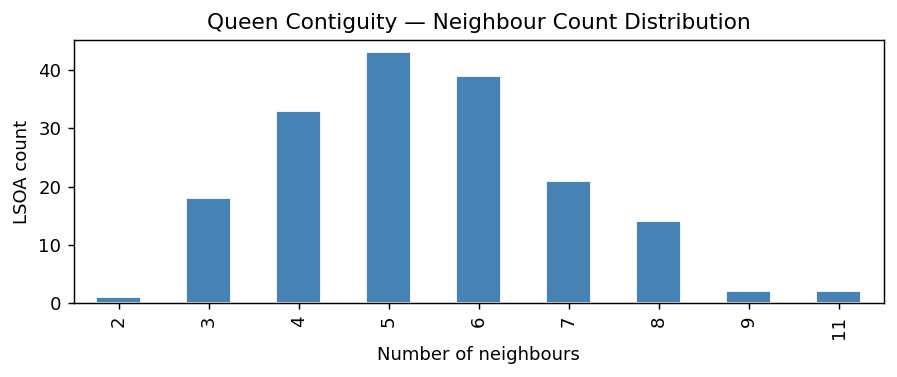

In [4]:
# Neighbour cardinality distribution
card = pd.Series(W.cardinalities).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 3))
card.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set(title='Queen Contiguity — Neighbour Count Distribution',
       xlabel='Number of neighbours', ylabel='LSOA count')
plt.tight_layout()
plt.show()

---
## 3. Global Moran's I

Tests whether the spatial distribution of HEI is random, clustered, or dispersed across Southwark as a whole.  
H₀: HEI is spatially random (no global autocorrelation).

In [5]:
y = geo['HEI_bayes'].values

mi = Moran(y, W, permutations=999)

print('='*45)
print('        Global Moran\'s I — HEI_bayes')
print('='*45)
print(f"  Moran's I   : {mi.I:.4f}")
print(f"  Expected I  : {mi.EI:.4f}")
print(f"  z-score     : {mi.z_norm:.4f}")
print(f"  p-value (norm)  : {mi.p_norm:.4f}")
print(f"  p-value (sim)   : {mi.p_sim:.4f}  [{mi.permutations} permutations]")
print('='*45)
sig = 'Reject H₀ — significant spatial clustering' if mi.p_sim < 0.05 else 'Fail to reject H₀'
print(f'  Conclusion  : {sig}')

        Global Moran's I — HEI_pca
  Moran's I   : 0.4915
  Expected I  : -0.0058
  z-score     : 10.6604
  p-value (norm)  : 0.0000
  p-value (sim)   : 0.0010  [999 permutations]
  Conclusion  : Reject H₀ — significant spatial clustering


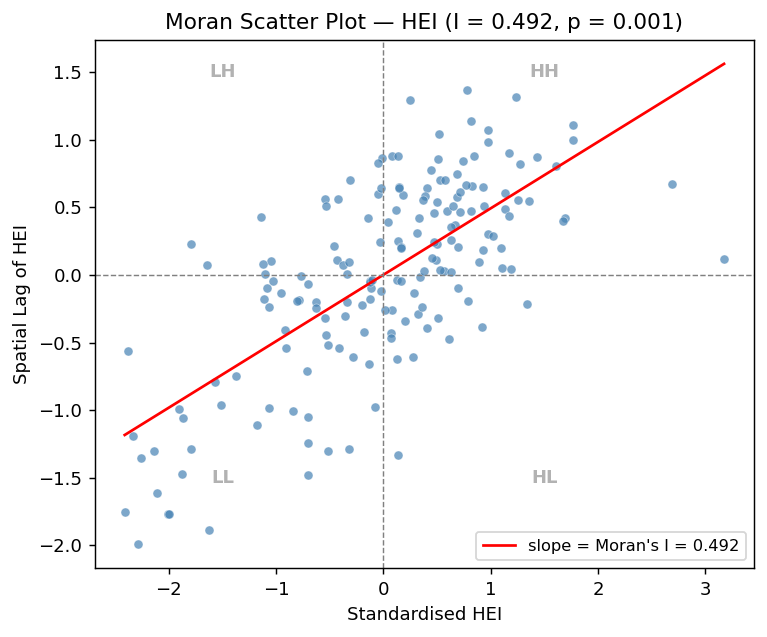

In [6]:
# Moran scatter plot
y_std  = (y - y.mean()) / y.std()
wy_std = libpysal.weights.lag_spatial(W, y_std)

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(y_std, wy_std, s=25, alpha=0.7, color='steelblue', edgecolors='white', lw=0.3)

# Regression line
m, b = np.polyfit(y_std, wy_std, 1)
xr   = np.linspace(y_std.min(), y_std.max(), 100)
ax.plot(xr, m * xr + b, 'r-', lw=1.5, label=f"slope = Moran's I = {mi.I:.3f}")

# Quadrant lines
ax.axhline(0, color='grey', lw=0.8, ls='--')
ax.axvline(0, color='grey', lw=0.8, ls='--')

# Quadrant labels
for txt, xy in [('HH', (1.5, 1.5)), ('LH', (-1.5, 1.5)),
                ('LL', (-1.5, -1.5)), ('HL', (1.5, -1.5))]:
    ax.text(*xy, txt, fontsize=10, color='grey', ha='center', va='center',
            fontweight='bold', alpha=0.6)

ax.set(xlabel='Standardised HEI', ylabel='Spatial Lag of HEI',
       title=f"Moran Scatter Plot — HEI (I = {mi.I:.3f}, p = {mi.p_sim:.3f})")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'moran_scatter_HEI.png'), dpi=150, bbox_inches='tight')
plt.show()

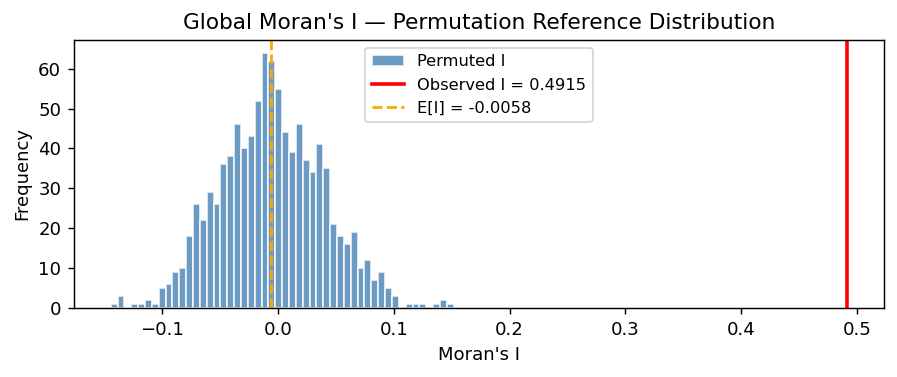

In [7]:
# Reference distribution from permutations
fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(mi.sim, bins=50, color='steelblue', edgecolor='white', alpha=0.8, label='Permuted I')
ax.axvline(mi.I,  color='red',    lw=2, label=f"Observed I = {mi.I:.4f}")
ax.axvline(mi.EI, color='orange', lw=1.5, ls='--', label=f"E[I] = {mi.EI:.4f}")
ax.set(title='Global Moran\'s I — Permutation Reference Distribution',
       xlabel="Moran's I", ylabel='Frequency')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'moran_permutation_dist.png'), dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Local Moran's I (LISA)

Identifies **where** spatial clusters and outliers occur at the LSOA level.

| Quadrant | Code | Interpretation |
|---|---|---|
| HH | 1 | High HEI surrounded by high HEI → **deprivation cluster** |
| LH | 2 | Low HEI surrounded by high HEI → spatial outlier |
| LL | 3 | Low HEI surrounded by low HEI → **good equity cluster** |
| HL | 4 | High HEI surrounded by low HEI → spatial outlier |

In [8]:
lm = Moran_Local(y, W, permutations=999, seed=42)

# Attach results to geo
geo['lisa_I']   = lm.Is        # local Moran's I
geo['lisa_q']   = lm.q         # quadrant (1=HH,2=LH,3=LL,4=HL)
geo['lisa_p']   = lm.p_sim     # simulated p-value

# Significance thresholds
SIG_05 = 0.05
SIG_01 = 0.01

# Cluster label (significant at p<0.05; else 'ns')
q_label = {1: 'HH', 2: 'LH', 3: 'LL', 4: 'HL'}
geo['lisa_label'] = np.where(
    geo['lisa_p'] < SIG_05,
    geo['lisa_q'].map(q_label),
    'ns'
)

print('LISA cluster counts (p < 0.05):')
print(geo['lisa_label'].value_counts())
print(f'\nSignificant LSOAs: {(geo["lisa_p"] < SIG_05).sum()} / {len(geo)}')

LISA cluster counts (p < 0.05):
lisa_label
ns    120
HH     25
LL     24
LH      3
HL      1
Name: count, dtype: int64

Significant LSOAs: 53 / 173


In [9]:
# Significance sensitivity at p<0.01
geo['lisa_label_01'] = np.where(
    geo['lisa_p'] < SIG_01,
    geo['lisa_q'].map(q_label),
    'ns'
)
print('LISA cluster counts (p < 0.01):')
print(geo['lisa_label_01'].value_counts())

LISA cluster counts (p < 0.01):
lisa_label_01
ns    144
LL     20
HH      9
Name: count, dtype: int64


---
## 5. LISA Cluster Map

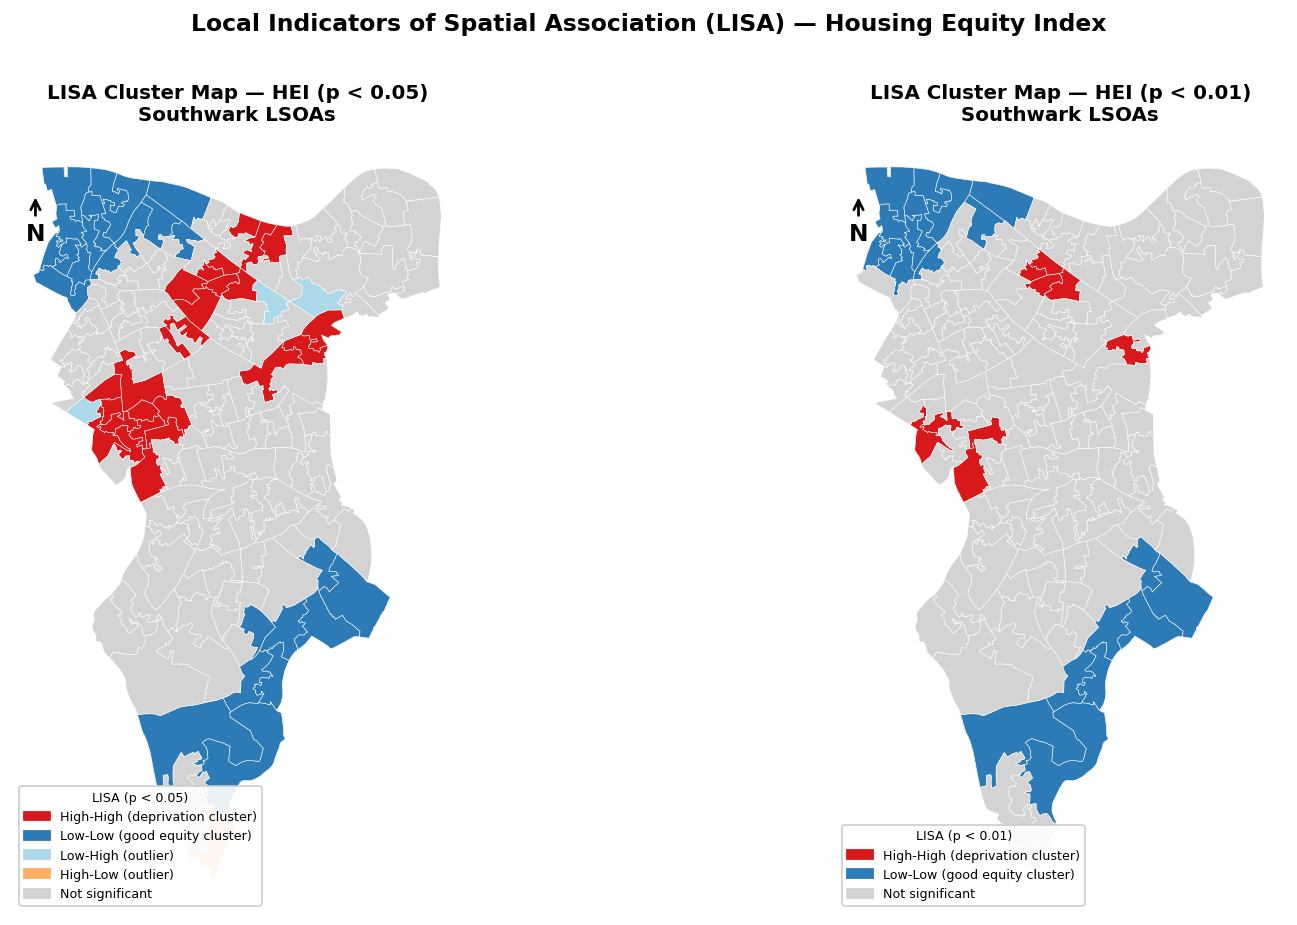

Saved → lisa_cluster_map.png


In [10]:
LISA_COLORS = {
    'HH': '#d7191c',   # red    — deprivation cluster
    'LL': '#2c7bb6',   # blue   — good equity cluster
    'LH': '#abd9e9',   # light blue — spatial outlier
    'HL': '#fdae61',   # orange — spatial outlier
    'ns': '#d3d3d3',   # light grey — not significant
}
LISA_LABELS = {
    'HH': 'High-High (deprivation cluster)',
    'LL': 'Low-Low (good equity cluster)',
    'LH': 'Low-High (outlier)',
    'HL': 'High-Low (outlier)',
    'ns': 'Not significant',
}

def plot_lisa_map(geo, label_col, sig_label, ax):
    for cluster, color in LISA_COLORS.items():
        subset = geo[geo[label_col] == cluster]
        subset.plot(ax=ax, color=color, edgecolor='white', linewidth=0.3)

    # Legend
    present = geo[label_col].unique()
    patches = [mpatches.Patch(color=LISA_COLORS[k], label=LISA_LABELS[k])
               for k in ['HH','LL','LH','HL','ns'] if k in present]
    ax.legend(handles=patches, loc='lower left', fontsize=7,
              framealpha=0.9, title=f'LISA ({sig_label})', title_fontsize=7)

    # North arrow
    ax.annotate('N', xy=(0.05, 0.92), xytext=(0.05, 0.86),
                xycoords='axes fraction', textcoords='axes fraction',
                fontsize=13, ha='center', fontweight='bold',
                arrowprops=dict(arrowstyle='->', lw=1.5))
    ax.axis('off')


fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for ax, label_col, sig in zip(axes,
                               ['lisa_label', 'lisa_label_01'],
                               ['p < 0.05',   'p < 0.01']):
    plot_lisa_map(geo, label_col, sig, ax)
    ax.set_title(f'LISA Cluster Map — HEI ({sig})\nSouthwark LSOAs', fontsize=11, fontweight='bold')

plt.suptitle('Local Indicators of Spatial Association (LISA) — Housing Equity Index',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'lisa_cluster_map.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved → lisa_cluster_map.png')

---
## 6. HH / LL Cluster Deep-Dive

In [11]:
# Descriptive statistics by LISA cluster type (p<0.05)
stats_cols = ['HEI_bayes','HCI','Affordability','median_house_price',
              'transport_ptai','hospital','avg_epc_rating_num','overcrowding_proxy']

# Merge additional columns from indices if needed
cluster_stats = (
    geo.groupby('lisa_label', observed=True)[stats_cols]
    .mean()
    .round(3)
    .rename(index={'HH':'HH (deprivation)', 'LL':'LL (good equity)',
                   'LH':'LH (outlier)', 'HL':'HL (outlier)', 'ns':'Not sig.'})
)
print('=== Mean values by LISA cluster type ===')
cluster_stats

=== Mean values by LISA cluster type ===


,HEI_pca,HCI,Affordability,median_house_price,transport_ptai,hospital,avg_epc_rating_num,overcrowding_proxy
lisa_label,,,,,,,,
HH (deprivation),0.5990,0.5130,0.1430,446005.6670,15.6180,1.0250,4.5280,0.0040
HL (outlier),0.4560,0.5130,0.1310,435000.0000,15.3890,1.4950,4.3680,0.0030
LH (outlier),0.4100,0.4020,0.0850,385873.3330,14.1590,1.5170,4.6490,0.0040
LL (good equity),0.1650,0.5010,0.3200,644096.0000,54.1630,1.5880,4.4420,0.0040
Not sig.,0.4510,0.4890,0.2190,536466.7590,20.9700,1.3770,4.4760,0.0040


In [12]:
# List HH cluster LSOAs (deprivation hotspots)
hh_lsoa = geo[geo['lisa_label'] == 'HH'][['lsoa21nm','HEI_bayes','HCI','Affordability',
                                            'transport_ptai','hospital','lisa_p']]\
              .sort_values('HEI_bayes', ascending=False)
print(f'=== High-High (HH) Deprivation Clusters — {len(hh_lsoa)} LSOAs ===')
print(hh_lsoa.to_string(index=False))

=== High-High (HH) Deprivation Clusters — 25 LSOAs ===
      lsoa21nm  HEI_pca    HCI  Affordability  transport_ptai  hospital  lisa_p
Southwark 021E   0.9119 0.8183         0.0488         23.2131    0.7127  0.0450
Southwark 004G   0.7479 0.4538         0.2195          9.2154    0.6075  0.0090
Southwark 004I   0.7479 0.6173         0.2195          9.2154    0.5216  0.0040
Southwark 020D   0.7190 0.5825         0.0792         18.7464    0.6363  0.0150
Southwark 021C   0.6874 0.6171         0.1307         33.8120    0.5622  0.0140
Southwark 004A   0.6587 0.5173         0.0979         10.9034    1.0801  0.0090
Southwark 021B   0.6525 0.6092         0.0348         21.9918    1.0484  0.0030
Southwark 004F   0.6418 0.5243         0.0252         15.2282    1.0738  0.0120
Southwark 017A   0.6061 0.5501         0.2906         19.9945    0.7519  0.0220
Southwark 020E   0.6058 0.5473         0.1400         16.7010    1.0342  0.0110
Southwark 017B   0.5987 0.5404         0.2067         20.5273    

In [13]:
# List LL cluster LSOAs (good equity areas)
ll_lsoa = geo[geo['lisa_label'] == 'LL'][['lsoa21nm','HEI_bayes','HCI','Affordability',
                                            'transport_ptai','hospital','lisa_p']]\
              .sort_values('HEI_bayes')
print(f'=== Low-Low (LL) Good Equity Clusters — {len(ll_lsoa)} LSOAs ===')
print(ll_lsoa.to_string(index=False))

=== Low-Low (LL) Good Equity Clusters — 24 LSOAs ===
      lsoa21nm  HEI_pca    HCI  Affordability  transport_ptai  hospital  lisa_p
Southwark 034A   0.0012 0.5858         0.4344         98.7026    1.0884  0.0010
Southwark 002B   0.0154 0.4885         0.5398         92.3200    1.0381  0.0030
Southwark 034E   0.0241 0.4968         0.1868        121.8870    0.7785  0.0010
Southwark 002C   0.0275 0.2861         0.9162         75.8419    0.7086  0.0090
Southwark 029C   0.0501 0.4864         0.1915          7.8708    3.2179  0.0090
Southwark 029B   0.0557 0.4594         0.1447          8.0044    3.5509  0.0020
Southwark 002D   0.0739 0.4038         0.1774         71.4120    0.9014  0.0020
Southwark 034D   0.0757 0.4944         0.6123        100.9260    0.6336  0.0010
Southwark 033A   0.0909 0.4624         0.1400          6.4332    2.9171  0.0090
Southwark 032E   0.0962 0.4791         0.2008          6.6686    3.0786  0.0010
Southwark 032B   0.0978 0.4170         0.0488          8.6823    3.

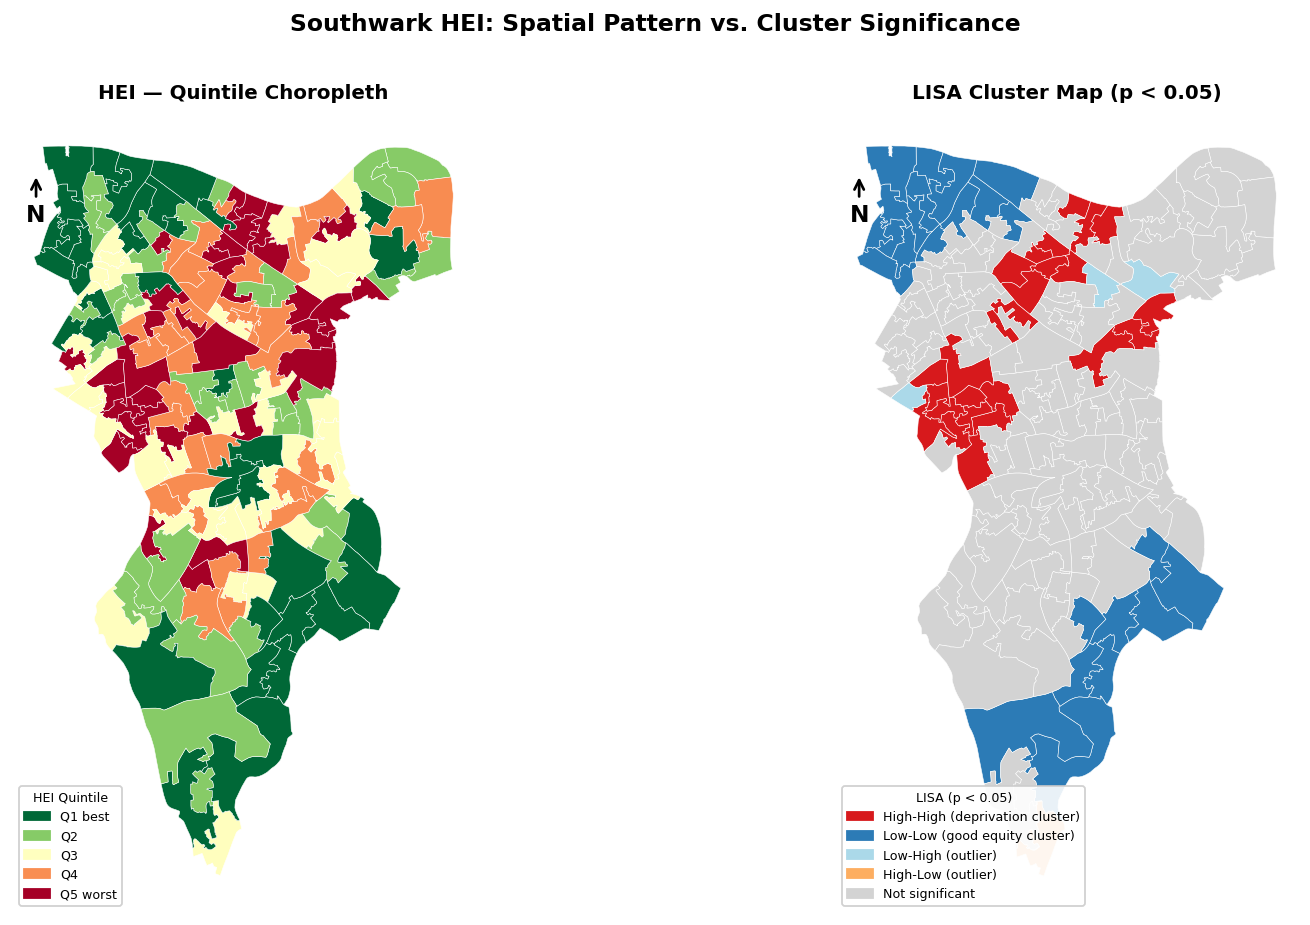

Saved → hei_vs_lisa_southwark.png


In [14]:
# Side-by-side: HEI choropleth vs LISA cluster map
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Left: HEI quintile choropleth — use pd.qcut (avoids mapclassify find_bin array issue)
ax = axes[0]
geo_plot = geo.copy()
geo_plot['_cls'] = pd.qcut(geo_plot['HEI_bayes'], q=5, labels=[0, 1, 2, 3, 4])
geo_plot['_cls'] = geo_plot['_cls'].astype(float)

geo_plot.plot(column='_cls', cmap='RdYlGn_r', ax=ax,
              linewidth=0.3, edgecolor='white',
              missing_kwds={'color': 'lightgrey'})

colors  = plt.get_cmap('RdYlGn_r', 5)
patches = [mpatches.Patch(color=colors(i / 4),
           label=['Q1 best', 'Q2', 'Q3', 'Q4', 'Q5 worst'][i]) for i in range(5)]
ax.legend(handles=patches, loc='lower left', fontsize=7,
          title='HEI Quintile', title_fontsize=7, framealpha=0.9)
ax.set_title('HEI — Quintile Choropleth', fontsize=11, fontweight='bold')
ax.axis('off')
ax.annotate('N', xy=(0.05, 0.92), xytext=(0.05, 0.86), xycoords='axes fraction',
            textcoords='axes fraction', fontsize=13, ha='center', fontweight='bold',
            arrowprops=dict(arrowstyle='->', lw=1.5))

# Right: LISA cluster map
plot_lisa_map(geo, 'lisa_label', 'p < 0.05', axes[1])
axes[1].set_title('LISA Cluster Map (p < 0.05)', fontsize=11, fontweight='bold')

fig.suptitle('Southwark HEI: Spatial Pattern vs. Cluster Significance',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'hei_vs_lisa_southwark.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved → hei_vs_lisa_southwark.png')

---
## 7. Global Moran's I for HCI and Affordability

In [15]:
results = []
for col, label in [('HEI_bayes','HEI'),('HCI','HCI'),('Affordability','Affordability')]:
    v = geo[col].dropna().values
    # Weights for non-missing subset
    geo_sub = geo.dropna(subset=[col]).reset_index(drop=True)
    W_sub = Queen.from_dataframe(geo_sub, silence_warnings=True)
    W_sub.transform = 'r'
    m = Moran(geo_sub[col].values, W_sub, permutations=999)
    results.append({
        'Index'    : label,
        "Moran's I": round(m.I, 4),
        'E[I]'     : round(m.EI, 4),
        'z-score'  : round(m.z_norm, 4),
        'p (norm)' : round(m.p_norm, 4),
        'p (sim)'  : round(m.p_sim, 4),
        'Significant': 'Yes' if m.p_sim < 0.05 else 'No'
    })

moran_table = pd.DataFrame(results).set_index('Index')
print('=== Global Moran\'s I Summary ===')
moran_table

=== Global Moran's I Summary ===


,Moran's I,E[I],z-score,p (norm),p (sim),Significant
Index,,,,,,
HEI,0.4915,-0.0058,10.6604,0.0000,0.0010,Yes
HCI,0.1621,-0.0058,3.5982,0.0003,0.0010,Yes
Affordability,0.4615,-0.0058,10.0158,0.0000,0.0010,Yes


## 8. Local Moran's I for HCI and Affordability

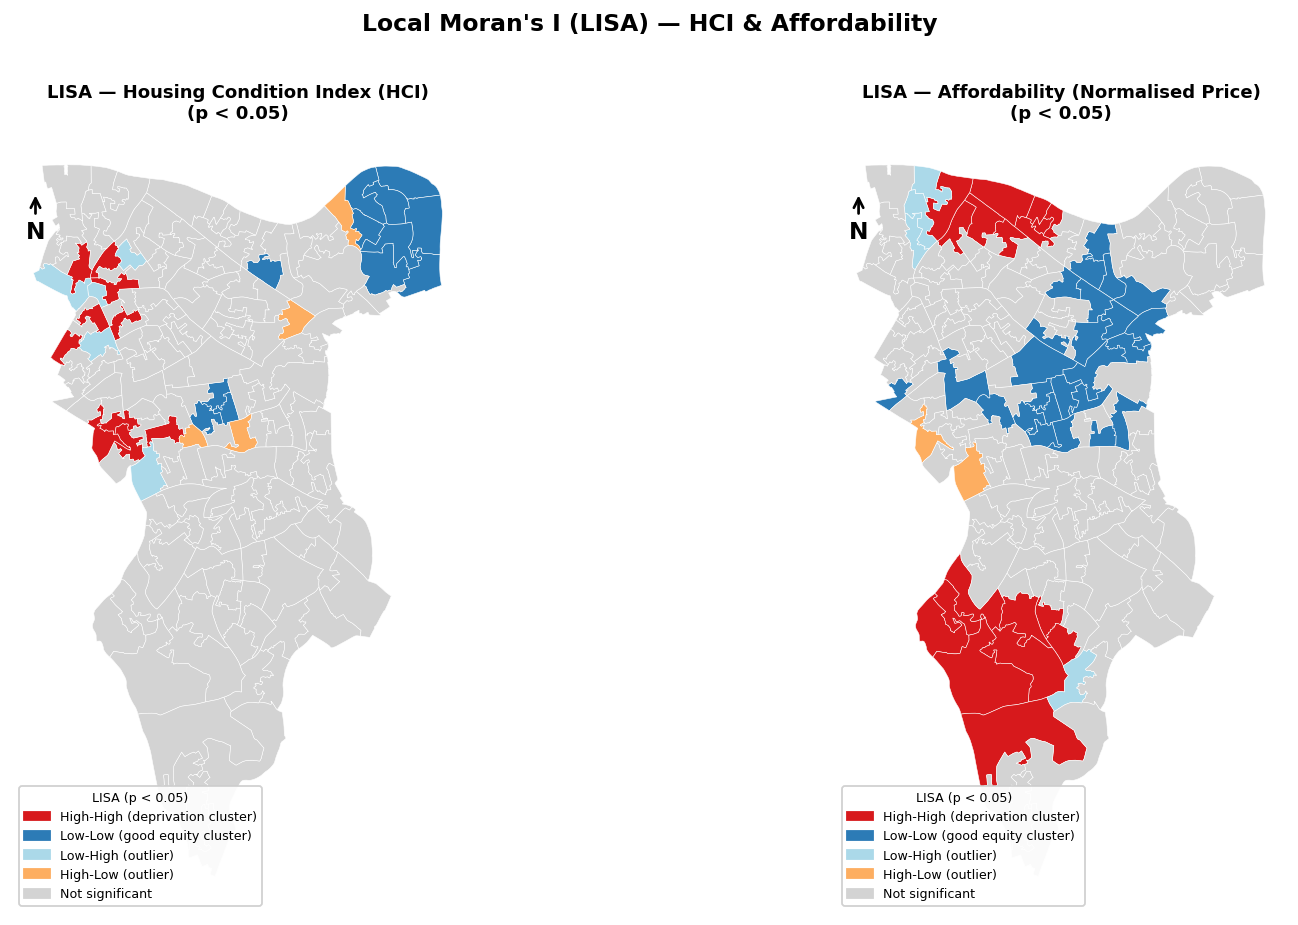

Saved → lisa_hci_affordability.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
q_label = {1:'HH', 2:'LH', 3:'LL', 4:'HL'}

for ax, col, title in zip(axes,
                           ['HCI', 'Affordability'],
                           ['Housing Condition Index (HCI)', 'Affordability (Normalised Price)']):
    geo_sub = geo.dropna(subset=[col]).reset_index(drop=True)
    W_sub = Queen.from_dataframe(geo_sub, silence_warnings=True)
    W_sub.transform = 'r'

    lm_sub = Moran_Local(geo_sub[col].values, W_sub, permutations=999, seed=42)

    geo_sub['_lisa_label'] = np.where(
        lm_sub.p_sim < 0.05,
        pd.Series(lm_sub.q).map(q_label),
        'ns'
    )
    plot_lisa_map(geo_sub, '_lisa_label', 'p < 0.05', ax)
    ax.set_title(f'LISA — {title}\n(p < 0.05)', fontsize=10, fontweight='bold')

plt.suptitle('Local Moran\'s I (LISA) — HCI & Affordability', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(DATA, 'lisa_hci_affordability.png'), dpi=200, bbox_inches='tight')
plt.show()
print('Saved → lisa_hci_affordability.png')

In [17]:
save_cols = ['lsoa21cd','lsoa21nm','HEI_bayes','HCI','Affordability',
             'lisa_I','lisa_q','lisa_p','lisa_label','lisa_label_01']

out = geo[save_cols].copy()
out.to_csv(os.path.join(DATA, 'southwark_lisa.csv'), index=False)

print('Saved → southwark_lisa.csv')
print(f'Shape: {out.shape}')
print('\nLISA cluster breakdown:')
print(out[['lisa_label','lsoa21nm']].groupby('lisa_label').count())

Saved → southwark_lisa.csv
Shape: (173, 10)

LISA cluster breakdown:
            lsoa21nm
lisa_label          
HH                25
HL                 1
LH                 3
LL                24
ns               120
